# Model Explainability
**SHAP values, Feature Importance, Partial Dependence Plots**

## 3.1 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings, os, joblib
warnings.filterwarnings("ignore")
from sklearn.inspection import PartialDependenceDisplay

os.makedirs("../results/explainability", exist_ok=True)
RANDOM_SEED = 42
print("Ready.")


Ready.


c:\Users\nabia\ALL_PROJECTS\Customer Churn\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3.2 Load data & best model

In [2]:
data  = joblib.load("../data/processed/churn_preprocessed.pkl")
meta  = joblib.load("../models/model_metadata.pkl")
model = joblib.load("../models/best_model.pkl")

X_train      = data["X_train"]
X_test       = data["X_test"]
y_test       = data["y_test"]
feature_cols = data["feature_cols"]

best_model_name = meta["name"]
print(f"Best model: {best_model_name}")
print(f"Features  : {len(feature_cols)}")


Best model: Random Forest
Features  : 23


## 3.3 Built-in feature importance (tree models)

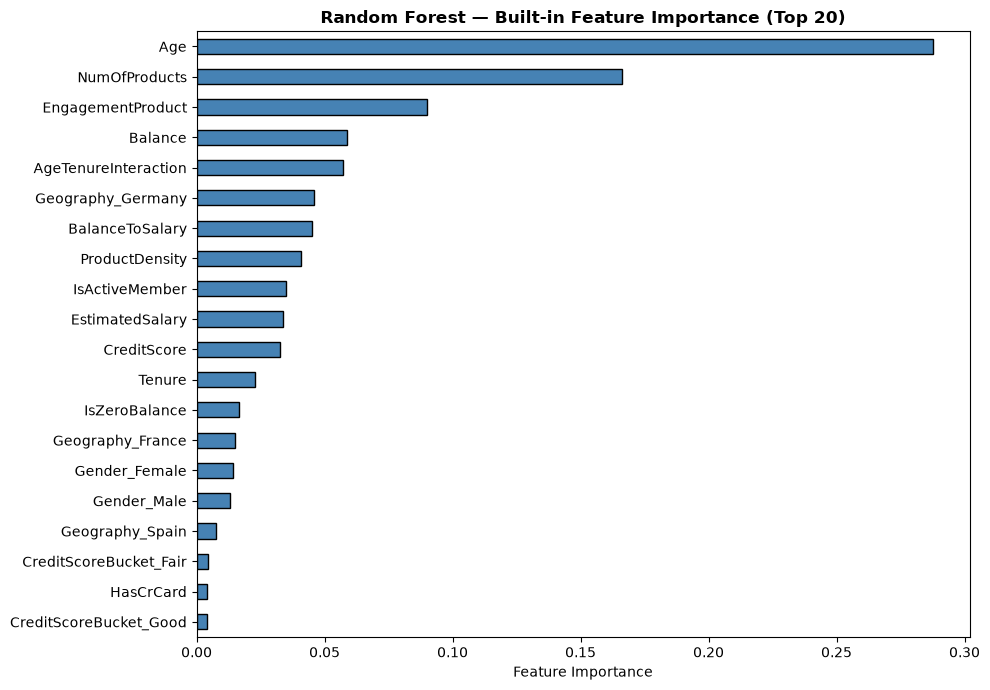

Top 10 features:
Age                     0.287604
NumOfProducts           0.166210
EngagementProduct       0.089881
Balance                 0.058621
AgeTenureInteraction    0.057187
Geography_Germany       0.045996
BalanceToSalary         0.045015
ProductDensity          0.040797
IsActiveMember          0.035015
EstimatedSalary         0.033712


In [3]:
if hasattr(model, "feature_importances_"):
    imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(10, 7))
    imp.head(20).sort_values().plot(kind="barh", color="steelblue", edgecolor="black")
    plt.xlabel("Feature Importance")
    plt.title(f"{best_model_name} — Built-in Feature Importance (Top 20)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../results/explainability/feature_importance_builtin.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Top 10 features:")
    print(imp.head(10).to_string())
else:
    print("Model does not have built-in feature_importances_.")


## 3.4 SHAP — Global explanations

In [4]:
# TreeExplainer for tree-based models
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("Raw SHAP shape:", np.array(shap_values).shape)

# ── Handle multi-output SHAP (shape: N x features x 2) ───────
# Random Forest / GradientBoosting return SHAP values for BOTH
# classes. We extract class-1 (Churn) contributions only.
if isinstance(shap_values, list):
    # Older SHAP: list [class0_array, class1_array]
    sv       = shap_values[1]                   # shape: (N, features)
    base_val = explainer.expected_value[1]
elif np.array(shap_values).ndim == 3:
    # Newer SHAP: single 3D array (N, features, classes)
    sv       = np.array(shap_values)[:, :, 1]  # shape: (N, features)
    base_val = float(np.array(explainer.expected_value).flat[1])
else:
    # Binary output already 2D — no slicing needed
    sv       = np.array(shap_values)
    base_val = float(np.array(explainer.expected_value).flat[-1])

print("Extracted SHAP shape (class 1):", sv.shape)
print("Base value (class 1)          :", round(base_val, 4))


Raw SHAP shape: (2000, 23, 2)
Extracted SHAP shape (class 1): (2000, 23)
Base value (class 1)          : 0.5005


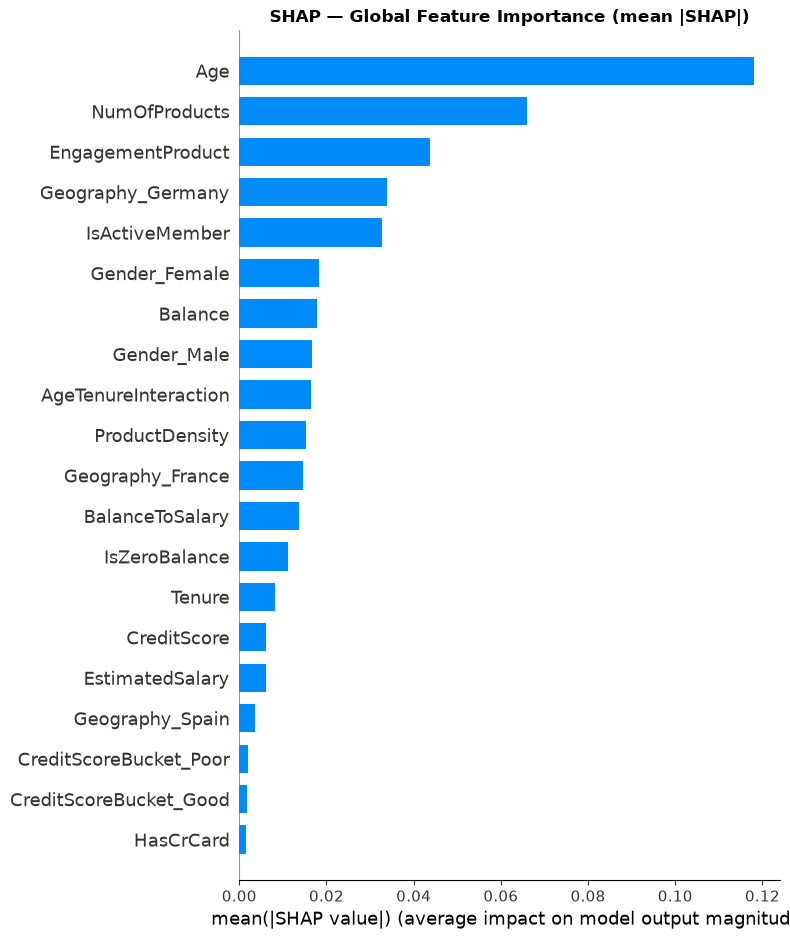

In [5]:
# ── Global bar — mean |SHAP| (class 1 = Churn) ───────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, feature_names=feature_cols,
                  plot_type="bar", show=False, max_display=20)
plt.title(f"SHAP — Global Feature Importance (mean |SHAP|)", fontweight="bold")
plt.tight_layout()
plt.savefig("../results/explainability/shap_global_bar.png", dpi=150, bbox_inches="tight")
plt.show()


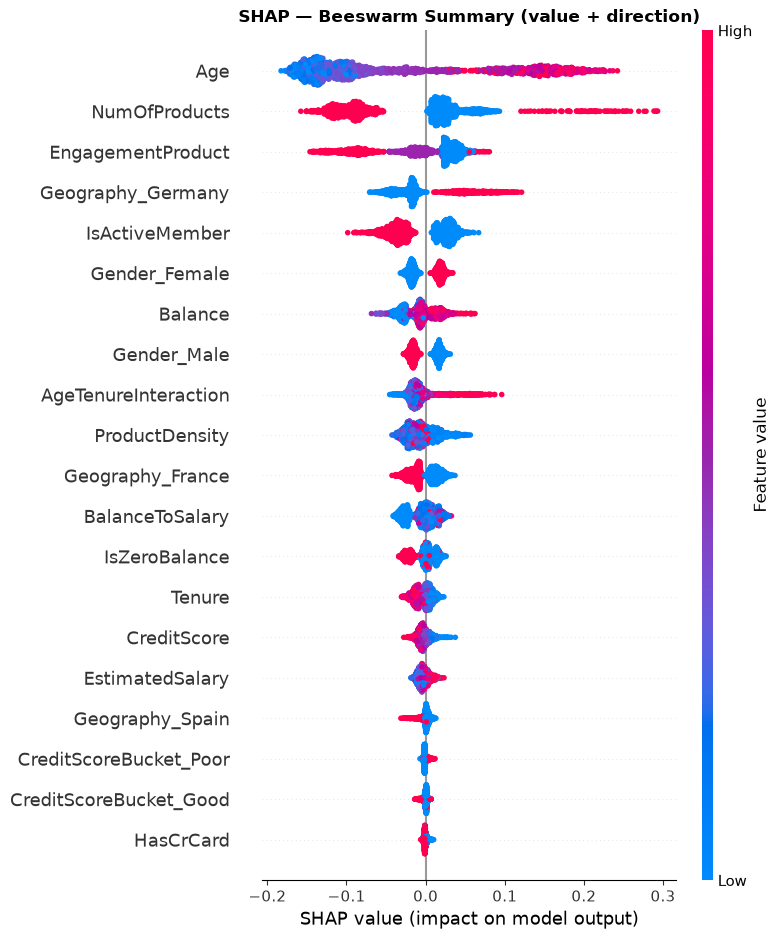

In [6]:
# ── Beeswarm summary plot ─────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_test, feature_names=feature_cols,
                  show=False, max_display=20)
plt.title("SHAP — Beeswarm Summary (value + direction)", fontweight="bold")
plt.tight_layout()
plt.savefig("../results/explainability/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()


## 3.5 SHAP — Local explanations

In [7]:
# Pick one high-risk and one low-risk customer
y_prob_test = model.predict_proba(X_test)[:, 1]
high_risk_idx = int(np.argmax(y_prob_test))
low_risk_idx  = int(np.argmin(y_prob_test))

print(f"High risk customer index: {high_risk_idx}  (prob={y_prob_test[high_risk_idx]:.3f})")
print(f"Low risk  customer index: {low_risk_idx}   (prob={y_prob_test[low_risk_idx]:.3f})")


High risk customer index: 338  (prob=0.954)
Low risk  customer index: 1559   (prob=0.019)


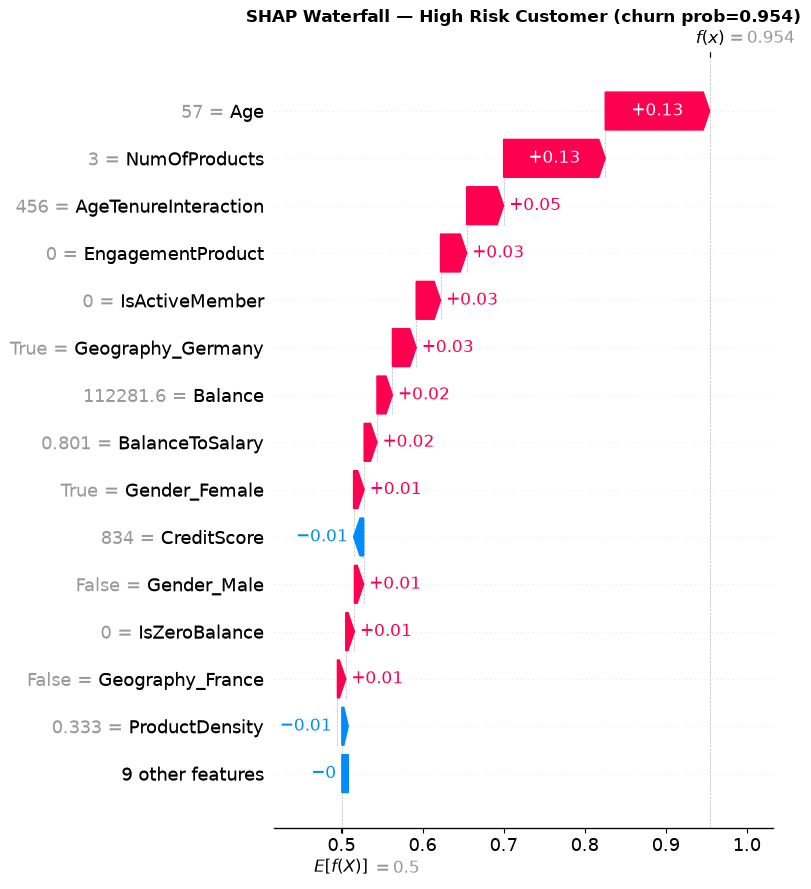

In [8]:
# Waterfall — High risk customer
# sv[i] is a 1D class-1 SHAP vector — no matrix dimension error
shap.waterfall_plot(
    shap.Explanation(
        values        = sv[high_risk_idx],        # shape (features,)
        base_values   = base_val,
        data          = X_test.iloc[high_risk_idx].values,
        feature_names = feature_cols
    ), show=False, max_display=15
)
plt.title(f"SHAP Waterfall — High Risk Customer (churn prob={y_prob_test[high_risk_idx]:.3f})",
          fontweight="bold")
plt.tight_layout()
plt.savefig("../results/explainability/shap_waterfall_highrisk.png", dpi=150, bbox_inches="tight")
plt.show()


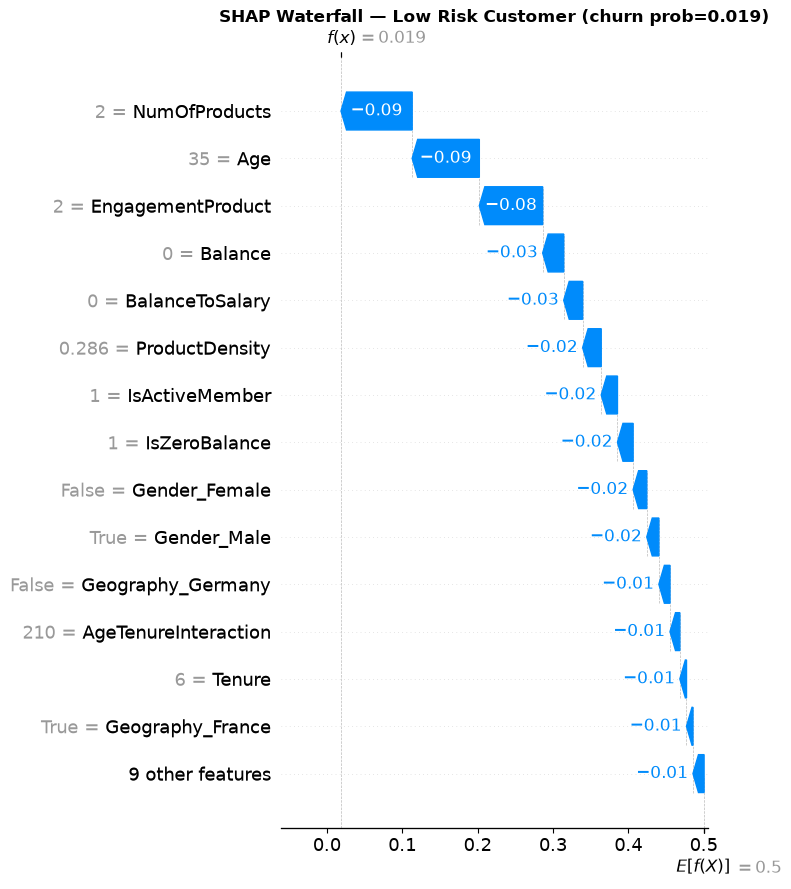

In [9]:
# Waterfall — Low risk customer
shap.waterfall_plot(
    shap.Explanation(
        values        = sv[low_risk_idx],          # shape (features,)
        base_values   = base_val,
        data          = X_test.iloc[low_risk_idx].values,
        feature_names = feature_cols
    ), show=False, max_display=15
)
plt.title(f"SHAP Waterfall — Low Risk Customer (churn prob={y_prob_test[low_risk_idx]:.3f})",
          fontweight="bold")
plt.tight_layout()
plt.savefig("../results/explainability/shap_waterfall_lowrisk.png", dpi=150, bbox_inches="tight")
plt.show()


## 3.6 SHAP Dependence Plots — Top features

<Figure size 640x480 with 0 Axes>

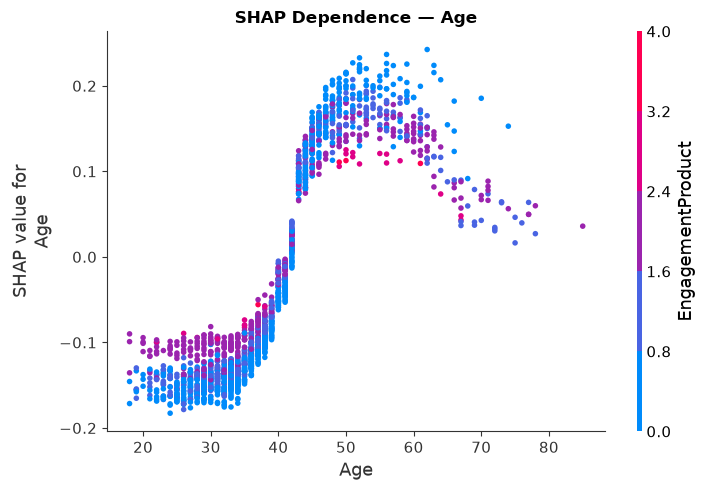

<Figure size 640x480 with 0 Axes>

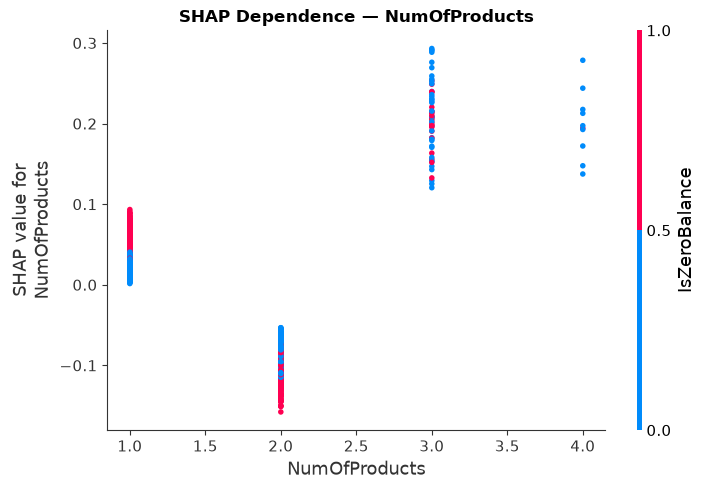

In [10]:
# mean_abs_shap from class-1 sv (shape: N x features)
mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=feature_cols)
top2 = mean_abs_shap.nlargest(2).index.tolist()

for feat in top2:
    plt.figure()
    shap.dependence_plot(feat, sv, X_test,         # ← sv not shap_values
                         feature_names=feature_cols, show=False)
    plt.title(f"SHAP Dependence — {feat}", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"../results/explainability/shap_dependence_{feat}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 3.7 Partial Dependence Plots (PDPs)

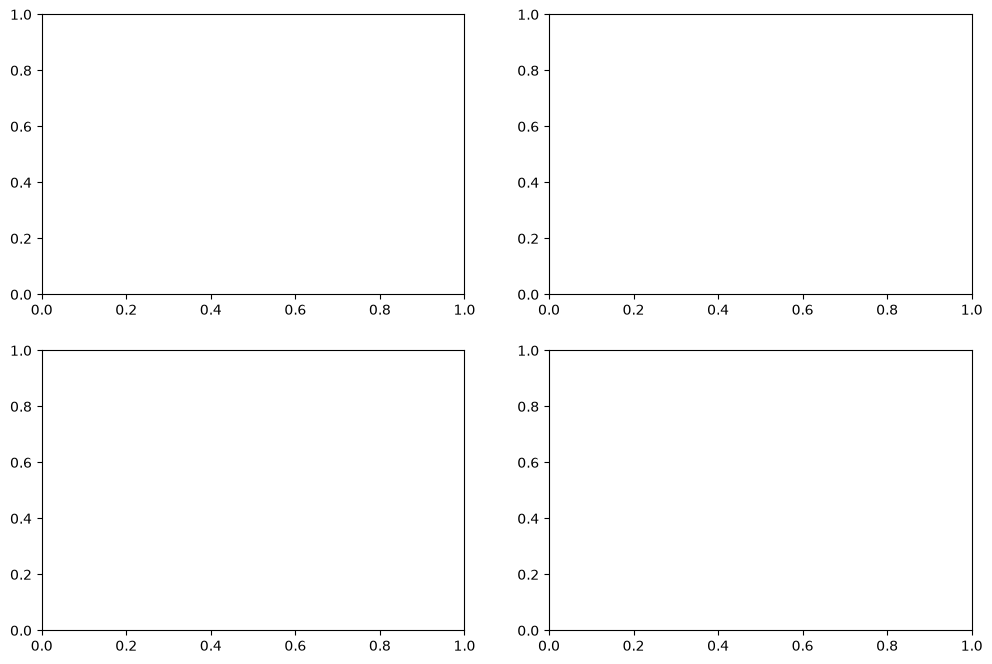

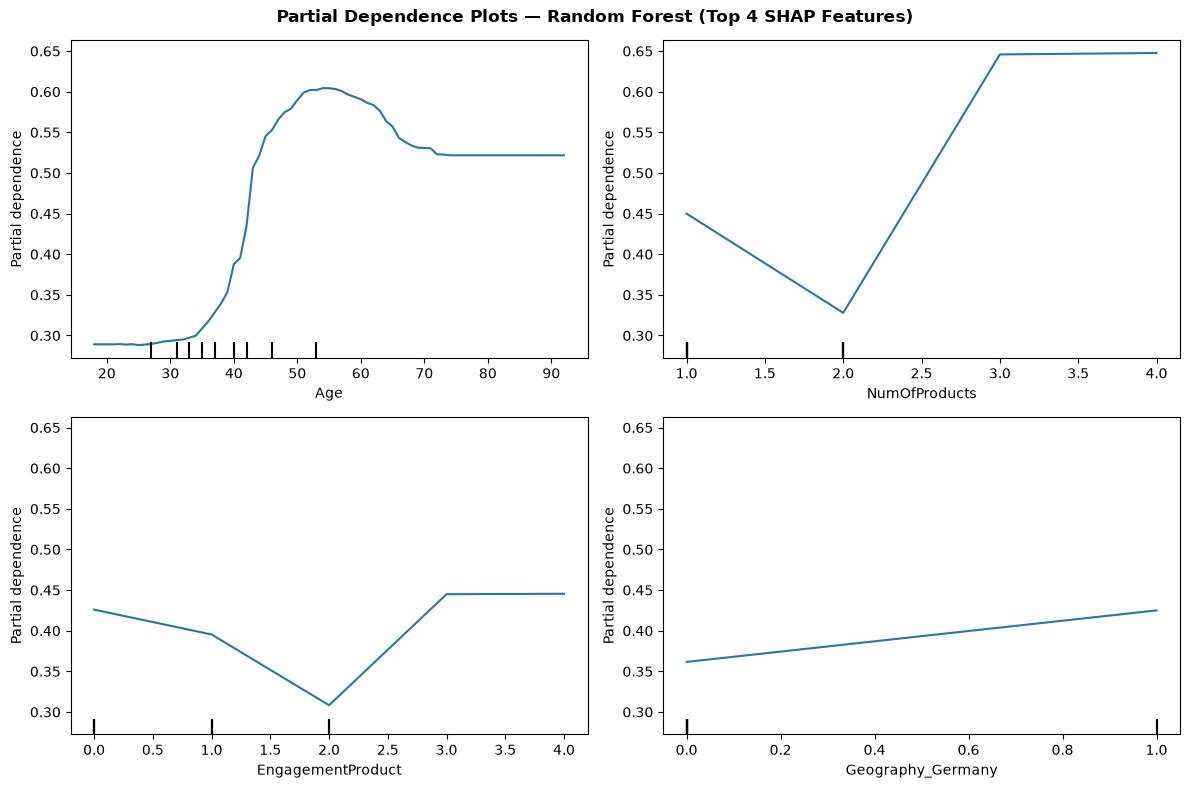

In [12]:
# PDP for top 4 features
top4 = mean_abs_shap.nlargest(4).index.tolist()

# ── Fix: convert to float64 — sklearn PDP doesn't accept integer columns ──
X_train_float = X_train.astype(float)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    model, X_train_float, top4,
    ax=axes.flatten(), kind="average",
    n_jobs=-1, random_state=RANDOM_SEED
)
plt.suptitle(f"Partial Dependence Plots — {best_model_name} (Top 4 SHAP Features)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/explainability/pdp_top4.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.8 SHAP Interaction — top feature pair

<Figure size 640x480 with 0 Axes>

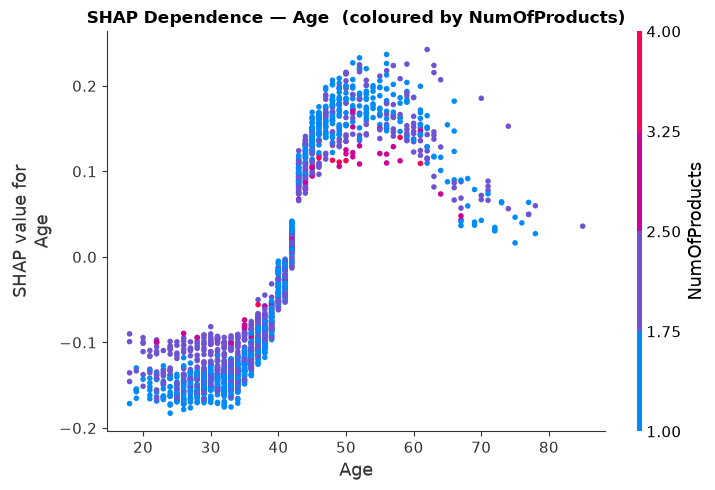

In [13]:
top1, top2_feat = mean_abs_shap.nlargest(2).index.tolist()

plt.figure()
shap.dependence_plot(top1, sv, X_test,             # ← sv not shap_values
                     interaction_index=top2_feat,
                     feature_names=feature_cols, show=False)
plt.title(f"SHAP Dependence — {top1}  (coloured by {top2_feat})", fontweight="bold")
plt.tight_layout()
plt.savefig("../results/explainability/shap_interaction.png", dpi=150, bbox_inches="tight")
plt.show()


## 3.9 Churn driver summary

In [15]:
shap_rank = mean_abs_shap.sort_values(ascending=False).reset_index()
shap_rank.columns = ["Feature", "Mean_SHAP"]
shap_rank["Rank"] = range(1, len(shap_rank)+1)
shap_rank.to_csv("../results/explainability/shap_feature_ranking.csv", index=False)

print("=== Top 15 Churn Drivers (SHAP) ===")
print(shap_rank.head(15).to_string(index=False))



=== Top 15 Churn Drivers (SHAP) ===
             Feature  Mean_SHAP  Rank
                 Age   0.118117     1
       NumOfProducts   0.065997     2
   EngagementProduct   0.043825     3
   Geography_Germany   0.033941     4
      IsActiveMember   0.032638     5
       Gender_Female   0.018230     6
             Balance   0.017868     7
         Gender_Male   0.016766     8
AgeTenureInteraction   0.016362     9
      ProductDensity   0.015221    10
    Geography_France   0.014559    11
     BalanceToSalary   0.013681    12
       IsZeroBalance   0.011067    13
              Tenure   0.008233    14
         CreditScore   0.006084    15
